# 04 — Muograma sintético del Fuego

## ¿Qué es un muograma?

Es una **imagen 2D** del cuerpo del volcán construida con muones. Cada pixel corresponde a una dirección $(\theta, \phi)$ del cielo vista desde el detector. El valor del pixel es la **transmisión**

$$T(\theta, \phi) = \frac{N_{\text{con roca}}(\theta, \phi)}{N_{\text{cielo abierto}}(\theta, \phi)}$$

es decir, la fracción de muones que sobreviven al pasar por la masa de roca que hay en esa dirección. Donde $T \to 1$ no hay volcán en el camino; donde $T \to 0$ la roca es tan gruesa que ningún muon la atraviesa.

## Las cuatro piezas del cálculo

1. **Geometría** del sistema: dónde está el volcán y dónde está el detector.
2. **Ray tracing**: para cada dirección angular, cuánta roca hay en el camino. Resultado: la *opacidad* $L(\theta, \phi)$ en g/cm² (densidad × longitud).
3. **Pérdida de energía**: cuánta energía pierde un muon al atravesar esa roca. Resultado: $p_{\min}(\theta, \phi)$ — momento mínimo necesario para que el muon llegue al detector.
4. **Integral del flujo**: sumar (vía Reyna) cuántos muones del flujo natural tienen $p > p_{\min}$ → transmisión.

## Caveat fuerte

Esta es la **primera iteración** y el volcán es un **cono sintético**, no la geometría real del Fuego. La cima, la base, la densidad y la posición del detector son razonables pero idealizadas. Cuando reemplacemos esto por un DEM (SRTM / ALOS), solo cambia el paso 2 (ray tracing contra terreno real). El resto del pipeline queda igual.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from analysis.muograma import (
    ConicalVolcano, rock_opacity_grid, csda_min_momentum,
    integrated_flux_above, transmission_map,
)

## 1. Geometría — Fuego sintético + detector

El Volcán de Fuego tiene su cima a **3,763 m**. Modelamos solo el cono superior (la parte que el detector "ve"): base a 2,500 m de altitud, radio base 1,500 m. Densidad de roca estándar: 2.65 g/cm³ (basalto típico).

Detector ubicado **4 km al este de la cima**, a **2,500 m de altitud** (consistente con el OBSLEV de la simulación de producción).

In [2]:
# Detector position from the curated INSIVUMEH station roster.
# Edit STATION_NAME / TARGET_VOLCAN to point the muogram at a different site.
STATION_NAME = "Fg16"
TARGET_VOLCAN = "fuego"

# Catalogued crater coordinates of Fuego (lat, lon). Used as the local
# (0, 0) origin of the synthetic cone — NB 04 has no DEM.
CRATER_LAT, CRATER_LON = 14.473, -90.880

import pandas as pd
from pyproj import Transformer

_sites = pd.read_csv(REPO_ROOT / "data" / "detector_sites.csv")
_mask = (_sites["name"] == STATION_NAME) & (_sites["target_volcan"] == TARGET_VOLCAN)
if not _mask.any():
    raise ValueError(f"({STATION_NAME!r}, {TARGET_VOLCAN!r}) not in data/detector_sites.csv")
_site = _sites[_mask].iloc[0]

# UTM 15N covers the Guatemalan volcanic chain
_tx = Transformer.from_crs("EPSG:4326", "EPSG:32615", always_xy=True)
_crater_x, _crater_y = _tx.transform(CRATER_LON, CRATER_LAT)
_station_x, _station_y = _tx.transform(_site["lon"], _site["lat"])

fuego = ConicalVolcano(
    summit_xyz=(0.0, 0.0, 3763.0),
    base_z=2500.0,
    base_radius_m=1500.0,
    density_gcc=2.65,
)
# Detector at the same elevation as the cone base (synthetic simplification —
# NB 04 has no DEM to read the actual terrain at this lat/lon).
detector_xyz = (
    float(_station_x - _crater_x),
    float(_station_y - _crater_y),
    fuego.base_z,
)

dx = fuego.summit_xyz[0] - detector_xyz[0]
dy = fuego.summit_xyz[1] - detector_xyz[1]
dz = fuego.summit_xyz[2] - detector_xyz[2]
dist_horiz = np.hypot(dx, dy)
elev_summit_deg = np.degrees(np.arctan2(dz, dist_horiz))
theta_summit_deg = 90.0 - elev_summit_deg
phi_summit_deg = np.degrees(np.arctan2(dy, dx)) % 360.0

print(f"Station: {_site['name']!r} ({_site['fuente']}) targeting {TARGET_VOLCAN}")
print(f"  Coords (lat, lon): ({_site['lat']:.4f}, {_site['lon']:.4f})")
print(f"  Distance to crater (per roster): {_site['dist_km']:.2f} km")
print()
print("Geometría del sistema:")
print(f"  Cono:    cima {fuego.summit_xyz[2]} m, base {fuego.base_z} m, "
      f"altura {fuego.height_m:.0f} m, radio base {fuego.base_radius_m:.0f} m")
print(f"           half-angle α = {np.degrees(np.arctan(fuego.tan_half_angle)):.1f}°, "
      f"densidad {fuego.density_gcc} g/cm³")
print(f"  Detector: ({detector_xyz[0]:.0f}, {detector_xyz[1]:.0f}, {detector_xyz[2]:.0f}) m")
print(f"  Distancia horizontal al eje: {dist_horiz:.0f} m")
print(f"  Cima vista desde el detector:")
print(f"     θ = {theta_summit_deg:.1f}°  (elevación = {elev_summit_deg:.1f}°)")
print(f"     φ = {phi_summit_deg:.0f}° (math convention: 0°=E, 90°=N, 180°=W, 270°=S)")

Geometría del sistema:
  Cono:    cima 3763.0 m, base 2500.0 m, altura 1263 m, radio base 1500 m
           half-angle α = 49.9°, densidad 2.65 g/cm³
  Detector: (4000, 0, 2500) m
  Distancia horizontal al eje: 4000 m
  Cima vista desde el detector:
     θ = 72.5°  (elevación = 17.5°)
     φ = 180° (180° = oeste, hacia la cima)


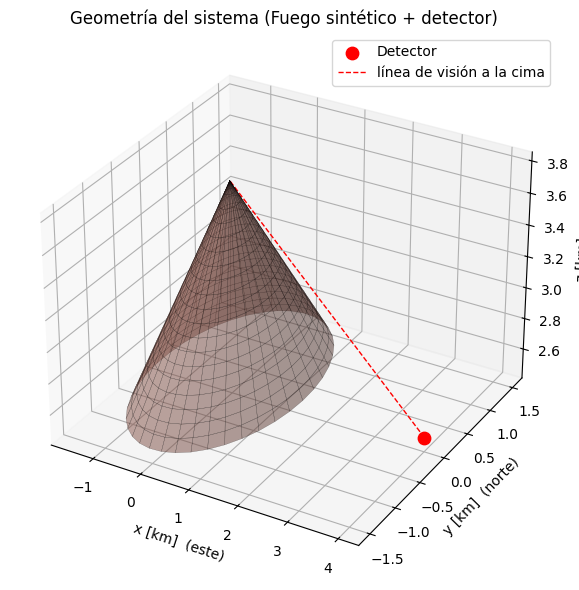

In [3]:
# Visualizacion 3D del setup
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')

# Generar superficie del cono
z_cone = np.linspace(fuego.base_z, fuego.summit_xyz[2], 20)
phi_c = np.linspace(0, 2*np.pi, 40)
Z, PHI = np.meshgrid(z_cone, phi_c, indexing='ij')
R = (fuego.summit_xyz[2] - Z) * fuego.tan_half_angle
X = fuego.summit_xyz[0] + R * np.cos(PHI)
Y = fuego.summit_xyz[1] + R * np.sin(PHI)
ax.plot_surface(X/1000, Y/1000, Z/1000, alpha=0.5, color='tab:brown', edgecolor='k', lw=0.2)

# Detector y rayo al sumit
ax.scatter(*[c/1000 for c in detector_xyz], color='red', s=80, label='Detector')
ax.plot([detector_xyz[0]/1000, fuego.summit_xyz[0]/1000],
        [detector_xyz[1]/1000, fuego.summit_xyz[1]/1000],
        [detector_xyz[2]/1000, fuego.summit_xyz[2]/1000],
        'r--', lw=1, label='línea de visión a la cima')

ax.set_xlabel('x [km]  (este)')
ax.set_ylabel('y [km]  (norte)')
ax.set_zlabel('z [km]')
ax.set_title('Geometría del sistema (Fuego sintético + detector)')
ax.legend()
plt.tight_layout()
fig.savefig(REPO_ROOT / 'docs/paper/figures' / 'fig_setup_3d_synthetic.png', bbox_inches='tight', dpi=300)
plt.show()

## 2. Ray tracing — opacidad $L(\theta, \phi)$

Para cada dirección $(\theta, \phi)$ lanzamos un rayo desde el detector y le sumamos masa por unidad de área en cada paso que cae dentro del cono. El resultado es la **opacidad** (a veces llamada *column density*) que pide la pérdida de energía de muones.

Cubrimos el cuadrante angular donde está la cima — entre $\theta = 40°$ y $\theta = 85°$, y entre $\phi = 120°$ y $\phi = 240°$ — con resolución fina (0.5°). Fuera de esa ventana no hay roca de todos modos.

In [4]:
theta_deg = np.arange(40.0, 85.5, 0.5)
# Re-center the azimuth grid on the crater direction (phi_summit_deg, computed
# above from the detector coords). ±60° gives a 120° wedge covering the
# volcanic edifice plus generous open-sky margin on both sides.
_phi_half = 60.0
phi_deg = np.arange(phi_summit_deg - _phi_half, phi_summit_deg + _phi_half + 0.5, 0.5)
theta_rad = np.radians(theta_deg)
phi_rad = np.radians(phi_deg)

L = rock_opacity_grid(
    fuego, detector_xyz, theta_rad, phi_rad,
    max_length_m=15_000.0, n_steps=600,  # ~25 m de resolucion espacial
)

print(f'Malla angular: {len(theta_deg)} × {len(phi_deg)} = {L.size} pixeles')
print(f'Pixeles con roca:   {(L > 0).sum()} ({(L > 0).mean():.1%})')
print(f'Opacidad max:       {L.max():.0f} g/cm² ≈ {L.max() / fuego.density_gcc / 100:.0f} m de roca')
print(f'Opacidad mediana en pixeles con roca: {np.median(L[L>0]):.0f} g/cm²')

Malla angular: 91 × 241 = 21931 pixeles
Pixeles con roca:   857 (3.9%)
Opacidad max:       583000 g/cm² ≈ 2200 m de roca
Opacidad mediana en pixeles con roca: 324625 g/cm²


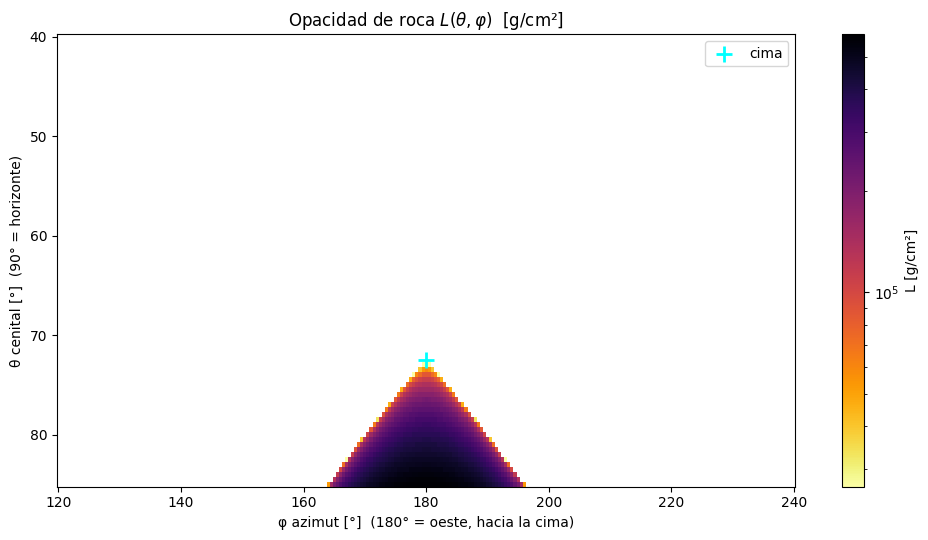

In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))
PHI, THETA = np.meshgrid(phi_deg, theta_deg)
# Para visualizar log de opacidad, agregamos un pequeno epsilon en los ceros
L_plot = np.where(L > 0, L, np.nan)
im = ax.pcolormesh(PHI, THETA, L_plot, cmap='inferno_r', shading='auto',
                    norm=LogNorm(vmin=max(L_plot[~np.isnan(L_plot)].min(), 1e2), vmax=L.max()))
ax.scatter(phi_summit_deg, theta_summit_deg, marker='+', s=120, color='cyan',
           label='cima', lw=2)
ax.set_xlabel('φ azimut [°]  (180° = oeste, hacia la cima)')
ax.set_ylabel('θ cenital [°]  (90° = horizonte)')
ax.invert_yaxis()  # theta pequeno (vertical) arriba
ax.set_title('Opacidad de roca $L(θ,φ)$  [g/cm²]')
plt.colorbar(im, ax=ax, label='L [g/cm²]')
ax.legend(loc='upper right')
plt.tight_layout()
fig.savefig(REPO_ROOT / 'docs/paper/figures' / 'fig_L_cone.png', bbox_inches='tight', dpi=300)
plt.show()

## 3. Pérdida de energía — $p_{\min}(L)$

Un muon que atraviesa roca pierde energía por dos canales:

$$-\frac{dE}{dX} = a + b \, E$$

- $a \approx 2$ MeV/(g/cm²) — **ionización** (constante, domina a $E \lesssim 100$ GeV)
- $b \approx 4 \times 10^{-6}$ (g/cm²)⁻¹ — **bremsstrahlung + producción de pares + interacciones fotonucleares** (proporcional a $E$, domina a $E \gtrsim 1$ TeV)

Integrando, el **rango CSDA** es $R(E) = (1/b) \ln(1 + b E / a)$. Invirtiendo, la energía mínima necesaria para atravesar una opacidad $X$ es:

$$E_{\min}(X) = \frac{a}{b}\left(e^{bX} - 1\right)$$

Para muones a estas energías, $E \approx pc$ (la masa $m_\mu \approx 0.1$ GeV es despreciable). Así que $p_{\min} \approx E_{\min}$.

In [6]:
# Tabla de referencia
print(f'{"Roca [m]":>10}  {"X [g/cm²]":>12}  {"E_min [GeV]":>14}')
print(f'{"-"*10}  {"-"*12}  {"-"*14}')
for rock_m in [10, 50, 100, 250, 500, 1000, 2000, 3000]:
    X = rock_m * 100 * fuego.density_gcc  # m × cm/m × g/cm³ = g/cm²
    e = csda_min_momentum(X)
    print(f'{rock_m:>10}  {X:>12.0f}  {e:>14.1f}')

  Roca [m]     X [g/cm²]     E_min [GeV]
----------  ------------  --------------
        10          2650             5.3
        50         13250            27.2
       100         26500            55.9
       250         66250           151.7
       500        132500           349.5
      1000        265000           943.2
      2000        530000          3665.6
      3000        795000         11523.4


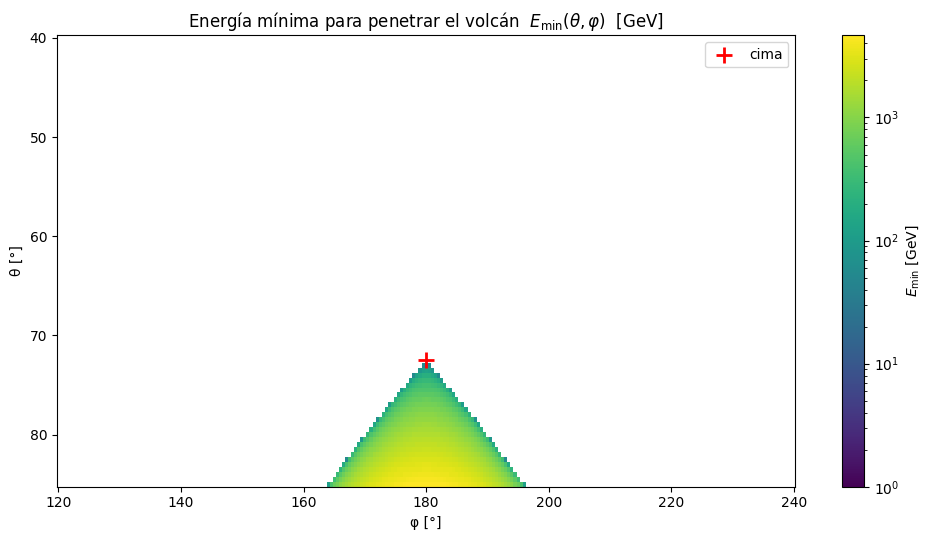

E_min máxima en el mapa: 4649 GeV (atravesando lo más grueso del cono)
E_min mediana en pixeles con roca: 1332 GeV


In [7]:
E_min = csda_min_momentum(L)

fig, ax = plt.subplots(figsize=(10, 5.5))
E_plot = np.where(E_min > 0.1, E_min, np.nan)
im = ax.pcolormesh(PHI, THETA, E_plot, cmap='viridis', shading='auto',
                    norm=LogNorm(vmin=1, vmax=E_min.max()))
ax.scatter(phi_summit_deg, theta_summit_deg, marker='+', s=120, color='red', label='cima', lw=2)
ax.set_xlabel('φ [°]')
ax.set_ylabel('θ [°]')
ax.invert_yaxis()
ax.set_title('Energía mínima para penetrar el volcán  $E_{\\min}(θ,φ)$  [GeV]')
plt.colorbar(im, ax=ax, label='$E_{\\min}$ [GeV]')
ax.legend(loc='upper right')
plt.tight_layout()
fig.savefig(REPO_ROOT / 'docs/paper/figures' / 'fig_emin_cone.png', bbox_inches='tight', dpi=300)
plt.show()

print(f'E_min máxima en el mapa: {E_min.max():.0f} GeV (atravesando lo más grueso del cono)')
print(f'E_min mediana en pixeles con roca: {np.median(E_min[L>0]):.0f} GeV')

## 4. Transmisión $T(\theta, \phi)$ — el muograma

Convertimos $p_{\min}$ a transmisión integrando el espectro de Reyna:

$$T(\theta, \phi) = \frac{\int_{p_{\min}}^{\infty} I_{\text{Reyna}}(p, \theta)\, dp}{\int_{p_{\text{thr}}}^{\infty} I_{\text{Reyna}}(p, \theta)\, dp}$$

con un umbral de detección $p_{\text{thr}} = 0.1$ GeV/c. Como Reyna ya validamos contra MC en el notebook 03, esto es coherente con nuestra simulación.

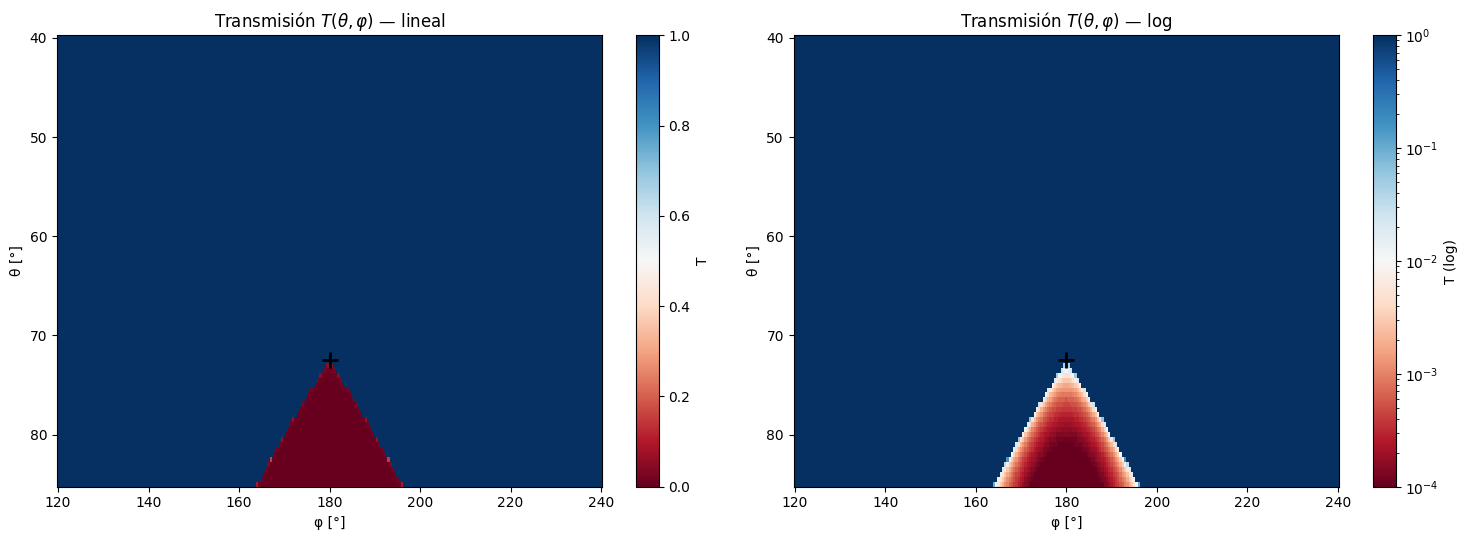

T mínima:                1.06e-05
T máxima (cielo abierto): 1.000
Pixeles con T < 0.5:     857 (3.9%)
Pixeles con T < 0.1:     855 (3.9%)


In [8]:
T = transmission_map(L, theta_rad, p_threshold_gevc=0.1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Panel izquierdo: T en escala lineal — muestra el contraste
im0 = axes[0].pcolormesh(PHI, THETA, T, cmap='RdBu', shading='auto', vmin=0, vmax=1)
axes[0].scatter(phi_summit_deg, theta_summit_deg, marker='+', s=140, color='black', lw=2)
axes[0].set_xlabel('φ [°]')
axes[0].set_ylabel('θ [°]')
axes[0].invert_yaxis()
axes[0].set_title('Transmisión $T(θ,φ)$ — lineal')
plt.colorbar(im0, ax=axes[0], label='T')

# Panel derecho: log para ver el gradiente cerca del centro
T_log = np.where(T > 0, T, np.nan)
im1 = axes[1].pcolormesh(PHI, THETA, T_log, cmap='RdBu', shading='auto',
                          norm=LogNorm(vmin=max(T_log[~np.isnan(T_log)].min(), 1e-4), vmax=1))
axes[1].scatter(phi_summit_deg, theta_summit_deg, marker='+', s=140, color='black', lw=2)
axes[1].set_xlabel('φ [°]')
axes[1].set_ylabel('θ [°]')
axes[1].invert_yaxis()
axes[1].set_title('Transmisión $T(θ,φ)$ — log')
plt.colorbar(im1, ax=axes[1], label='T (log)')

plt.tight_layout()
fig.savefig(REPO_ROOT / 'docs/paper/figures' / 'fig_T_cone.png', bbox_inches='tight', dpi=300)
plt.show()

print(f'T mínima:                {T.min():.2e}')
print(f'T máxima (cielo abierto): {T.max():.3f}')
print(f'Pixeles con T < 0.5:     {(T < 0.5).sum()} ({(T < 0.5).mean():.1%})')
print(f'Pixeles con T < 0.1:     {(T < 0.1).sum()} ({(T < 0.1).mean():.1%})')

## 5. Perfil vertical a través de la cima

Cortamos el muograma en $\phi = \phi_{\text{cima}}$ y graficamos opacidad, $E_{\min}$ y transmisión en función de $\theta$. Es la "radiografía 1D" a través del eje del volcán — la firma más clara para distinguir señal de fondo.

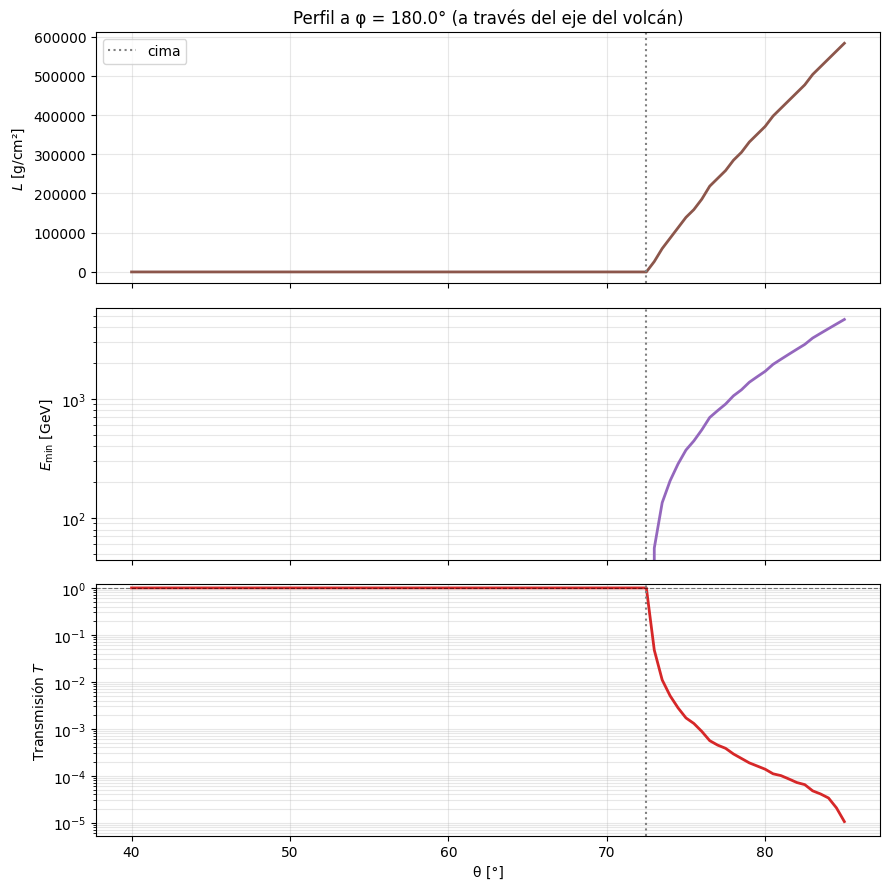

In [9]:
# Indice de phi mas cercano a la cima
j_phi = int(np.argmin(np.abs(phi_deg - phi_summit_deg)))
L_slice    = L[:, j_phi]
Emin_slice = E_min[:, j_phi]
T_slice    = T[:, j_phi]

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

axes[0].plot(theta_deg, L_slice, color='tab:brown', lw=2)
axes[0].set_ylabel('$L$ [g/cm²]')
axes[0].set_title(f'Perfil a φ = {phi_deg[j_phi]:.1f}° (a través del eje del volcán)')
axes[0].axvline(theta_summit_deg, color='gray', ls=':', label='cima')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(theta_deg, Emin_slice, color='tab:purple', lw=2)
axes[1].set_ylabel('$E_{\\min}$ [GeV]')
axes[1].set_yscale('log')
axes[1].axvline(theta_summit_deg, color='gray', ls=':')
axes[1].grid(alpha=0.3, which='both')

axes[2].plot(theta_deg, T_slice, color='tab:red', lw=2)
axes[2].set_ylabel('Transmisión $T$')
axes[2].set_xlabel('θ [°]')
axes[2].set_yscale('log')
axes[2].set_ylim(max(T_slice[T_slice>0].min()*0.5, 1e-6), 1.2)
axes[2].axvline(theta_summit_deg, color='gray', ls=':')
axes[2].axhline(1.0, color='black', ls='--', lw=0.8, alpha=0.5)
axes[2].grid(alpha=0.3, which='both')

plt.tight_layout()
fig.savefig(REPO_ROOT / 'docs/paper/figures' / 'fig_profile_cone.png', bbox_inches='tight', dpi=300)
plt.show()

---

## Lectura del muograma

Las tres figuras juntas cuentan la historia:

- **El mapa de opacidad** muestra la sombra del cono — más oscuro donde hay más roca. La cruz marca la cima.
- **El mapa de $E_{\min}$** dice que para *ver* el centro del volcán haría falta un detector sensible a varios cientos de GeV. Por eso los detectores de muografía son "telescopios pesados" con buena resolución de momento.
- **El muograma de transmisión** es la imagen que un detector real produciría — vacía afuera del cono (T≈1), oscura adentro (T≪1). El gradiente del borde es donde la muografía es más sensible a inhomogeneidades de densidad.

## Próximos pasos (en orden)

1. **DEM real del Fuego.** Bajar SRTM 30m (o ALOS 12.5m) y reemplazar `rock_opacity_grid` por una versión que muestrée el terreno en lugar del cono. El resto del pipeline (CSDA, integral del flujo) queda igual.
2. **Comparación con CORSIKA.** En vez de Reyna, integrar el flujo desde el binario MC directamente. Comparar muograma analítico vs MC para ver si las diferencias del notebook 03 (~20% en bines intermedios) afectan la transmisión.
3. **Mapa de densidades $\rho(\theta, \phi)$**: dado que conocemos la geometría del DEM, dividir la opacidad medida entre la longitud de cuerda para obtener una densidad efectiva. Anomalías son cámaras magmáticas o cavidades.
4. **Tiempo de exposición.** Convertir T(θ,φ) a número absoluto de eventos por pixel × área del detector × tiempo, usando la normalización absoluta del flujo (no implementada aún). Esto da el tiempo de medición necesario para alcanzar un dado SNR.
5. **ML.** Con el pipeline completo, las dos opciones (surrogate vs super-resolution) son comparables sobre datos concretos.